In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
df = pd.read_csv('job_resume_dataset.csv')
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (30, 5)


,Resume_ID,Candidate_Name,Resume_Text,Qualification,Target_Role
0,R001,Ananya Sharma,"Python, machine learning, pandas, numpy, sciki...",MCA,Data Scientist
1,R002,Rahul Kumar,"Java, Spring Boot, REST API, MySQL, Git, HTML,...",B.Tech Computer Science,Java Developer
2,R003,Priya Nair,"Python, pandas, numpy, SQL, Tableau, Power BI,...",M.Sc Statistics,Data Analyst
3,R004,Arjun Singh,"HTML, CSS, JavaScript, React, Bootstrap, Git, ...",B.Tech IT,Frontend Developer
4,R005,Meera Iyer,"Python, TensorFlow, Keras, deep learning, NLP,...",M.Tech AI,AI Engineer


## 1. Preprocess Resume Text

In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Resume'] = df['Resume_Text'].apply(preprocess_text)
display(df[['Candidate_Name','Resume_Text','Cleaned_Resume']].head())

,Candidate_Name,Resume_Text,Cleaned_Resume
0,Ananya Sharma,"Python, machine learning, pandas, numpy, sciki...",python machine learning pandas numpy scikit le...
1,Rahul Kumar,"Java, Spring Boot, REST API, MySQL, Git, HTML,...",java spring boot rest api mysql git html css j...
2,Priya Nair,"Python, pandas, numpy, SQL, Tableau, Power BI,...",python pandas numpy sql tableau power bi excel...
3,Arjun Singh,"HTML, CSS, JavaScript, React, Bootstrap, Git, ...",html css javascript react bootstrap git rest api
4,Meera Iyer,"Python, TensorFlow, Keras, deep learning, NLP,...",python tensorflow keras deep learning nlp comp...


## 2. Extract Skills and Qualifications

In [4]:
skills = [
    'python','java','sql','pandas','numpy','scikit-learn','machine learning',
    'tensorflow','keras','pytorch','deep learning','nlp','computer vision',
    'opencv','statistics','tableau','power bi','excel','data visualization',
    'spring boot','spring','hibernate','rest api','mysql','postgresql','docker',
    'html','css','javascript','react','typescript','bootstrap','git','redux'
]

def extract_skills(text):
    text = text.lower()
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return ', '.join(found)

df['Extracted_Skills'] = df['Cleaned_Resume'].apply(extract_skills)
display(df[['Candidate_Name','Qualification','Extracted_Skills']].head(10))

,Candidate_Name,Qualification,Extracted_Skills
0,Ananya Sharma,MCA,"python, sql, pandas, numpy, machine learning, ..."
1,Rahul Kumar,B.Tech Computer Science,"java, sql, spring boot, spring, rest api, mysq..."
2,Priya Nair,M.Sc Statistics,"python, sql, pandas, numpy, statistics, tablea..."
3,Arjun Singh,B.Tech IT,"java, rest api, html, css, javascript, react, ..."
4,Meera Iyer,M.Tech AI,"python, numpy, tensorflow, keras, deep learnin..."
5,Vikram Rao,B.Tech Computer Science,"java, sql, spring, hibernate, rest api, postgr..."
6,Sneha Patel,MBA Business Analytics,"python, sql, pandas, tableau, power bi, excel,..."
7,Karan Mehta,B.Tech AI,"python, sql, machine learning, statistics"
8,Divya Menon,B.Tech IT,"java, html, css, javascript, react, typescript..."
9,Rohan Das,MCA,"python, machine learning, tensorflow, pytorch,..."


## 3. Define Job Roles and Required Skills

In [5]:
job_roles = {
    'Data Scientist': 'python machine learning pandas numpy scikit-learn sql statistics data visualization',
    'Data Analyst': 'sql excel power bi tableau python pandas statistics data visualization',
    'Java Developer': 'java spring boot rest api mysql sql git hibernate docker',
    'Frontend Developer': 'html css javascript react typescript bootstrap git',
    'AI Engineer': 'python tensorflow pytorch deep learning nlp computer vision opencv machine learning'
}

for role, required in job_roles.items():
    print(role, '->', required)

Data Scientist -> python machine learning pandas numpy scikit-learn sql statistics data visualization
Data Analyst -> sql excel power bi tableau python pandas statistics data visualization
Java Developer -> java spring boot rest api mysql sql git hibernate docker
Frontend Developer -> html css javascript react typescript bootstrap git
AI Engineer -> python tensorflow pytorch deep learning nlp computer vision opencv machine learning


## 4. Match Resumes with Job Roles using TF-IDF

In [6]:
all_documents = list(df['Cleaned_Resume']) + list(job_roles.values())
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_documents)

resume_vectors = tfidf_matrix[:len(df)]
role_vectors = tfidf_matrix[len(df):]

similarity_matrix = cosine_similarity(resume_vectors, role_vectors)

role_names = list(job_roles.keys())
df['Best_Matched_Role'] = [role_names[i] for i in similarity_matrix.argmax(axis=1)]
df['Match_Score'] = similarity_matrix.max(axis=1) * 100

display(df[['Candidate_Name','Best_Matched_Role','Match_Score']].head(10))

,Candidate_Name,Best_Matched_Role,Match_Score
0,Ananya Sharma,Data Scientist,95.364473
1,Rahul Kumar,Java Developer,69.655934
2,Priya Nair,Data Analyst,78.823176
3,Arjun Singh,Frontend Developer,77.203361
4,Meera Iyer,AI Engineer,67.142227
5,Vikram Rao,Java Developer,73.755407
6,Sneha Patel,Data Analyst,94.806269
7,Karan Mehta,Data Scientist,64.924148
8,Divya Menon,Frontend Developer,100.000000
9,Rohan Das,AI Engineer,79.648608


## 5. Candidate Shortlist

In [7]:
threshold = 30
shortlist = df[df['Match_Score'] >= threshold].copy()
shortlist = shortlist.sort_values('Match_Score', ascending=False)

print('Shortlisted candidates:', len(shortlist))
display(shortlist[['Resume_ID','Candidate_Name','Qualification','Best_Matched_Role','Match_Score','Extracted_Skills']])

Shortlisted candidates: 30


,Resume_ID,Candidate_Name,Qualification,Best_Matched_Role,Match_Score,Extracted_Skills
8,R009,Divya Menon,B.Tech IT,Frontend Developer,100.000000,"java, html, css, javascript, react, typescript..."
0,R001,Ananya Sharma,MCA,Data Scientist,95.364473,"python, sql, pandas, numpy, machine learning, ..."
6,R007,Sneha Patel,MBA Business Analytics,Data Analyst,94.806269,"python, sql, pandas, tableau, power bi, excel,..."
21,R022,Akash Jain,B.Tech IT,Java Developer,90.237156,"java, sql, spring boot, spring, rest api, mysq..."
14,R015,Aisha Khan,M.Tech AI,AI Engineer,89.649044,"python, tensorflow, pytorch, deep learning, co..."
20,R021,Riya Thomas,MBA,Data Analyst,88.046149,"python, sql, pandas, power bi, excel, data vis..."
22,R023,Nandini Rao,B.Tech Computer Science,Frontend Developer,87.954375,"java, html, css, javascript, react, bootstrap,..."
27,R028,Abhishek Sinha,BCA,Frontend Developer,87.954375,"java, html, css, javascript, react, bootstrap,..."
16,R017,Kavya Reddy,B.Tech Computer Science,Java Developer,85.094430,"java, sql, spring boot, spring, hibernate, res..."
28,R029,Tanvi Kulkarni,MCA,Data Scientist,81.334786,"python, sql, pandas, machine learning"


## 6. Role-wise Shortlist

In [8]:
for role in role_names:
    print('\n' + '='*50)
    print('ROLE:', role)
    role_shortlist = shortlist[shortlist['Best_Matched_Role'] == role]
    display(role_shortlist[['Candidate_Name','Qualification','Match_Score','Extracted_Skills']])


ROLE: Data Scientist


,Candidate_Name,Qualification,Match_Score,Extracted_Skills
0,Ananya Sharma,MCA,95.364473,"python, sql, pandas, numpy, machine learning, ..."
28,Tanvi Kulkarni,MCA,81.334786,"python, sql, pandas, machine learning"
23,Siddharth Paul,MCA,71.937706,"python, sql, pandas, numpy, machine learning, ..."
7,Karan Mehta,B.Tech AI,64.924148,"python, sql, machine learning, statistics"
18,Ishita Bose,M.Sc Data Science,64.924148,"python, sql, machine learning, statistics"



ROLE: Data Analyst


,Candidate_Name,Qualification,Match_Score,Extracted_Skills
6,Sneha Patel,MBA Business Analytics,94.806269,"python, sql, pandas, tableau, power bi, excel,..."
20,Riya Thomas,MBA,88.046149,"python, sql, pandas, power bi, excel, data vis..."
10,Neha Verma,BCA,80.810425,"python, sql, statistics, tableau, power bi, excel"
25,Harish Babu,BBA,80.810425,"python, sql, statistics, tableau, power bi, excel"
15,Manish Joshi,B.Com,79.795451,"python, sql, pandas, tableau, power bi, excel"
2,Priya Nair,M.Sc Statistics,78.823176,"python, sql, pandas, numpy, statistics, tablea..."



ROLE: Java Developer


,Candidate_Name,Qualification,Match_Score,Extracted_Skills
21,Akash Jain,B.Tech IT,90.237156,"java, sql, spring boot, spring, rest api, mysq..."
16,Kavya Reddy,B.Tech Computer Science,85.094430,"java, sql, spring boot, spring, hibernate, res..."
11,Aditya Shah,B.Tech Computer Science,75.859618,"java, sql, spring boot, spring, rest api, mysq..."
5,Vikram Rao,B.Tech Computer Science,73.755407,"java, sql, spring, hibernate, rest api, postgr..."
1,Rahul Kumar,B.Tech Computer Science,69.655934,"java, sql, spring boot, spring, rest api, mysq..."
26,Swati Mishra,B.Tech Computer Science,64.309994,"java, sql, spring, hibernate, rest api, postgr..."



ROLE: Frontend Developer


,Candidate_Name,Qualification,Match_Score,Extracted_Skills
8,Divya Menon,B.Tech IT,100.000000,"java, html, css, javascript, react, typescript..."
22,Nandini Rao,B.Tech Computer Science,87.954375,"java, html, css, javascript, react, bootstrap,..."
27,Abhishek Sinha,BCA,87.954375,"java, html, css, javascript, react, bootstrap,..."
17,Nikhil Roy,BCA,80.444340,"java, rest api, html, css, javascript, react, ..."
3,Arjun Singh,B.Tech IT,77.203361,"java, rest api, html, css, javascript, react, ..."
12,Pooja Gupta,B.Tech IT,62.112134,"java, html, css, javascript, react, git, redux"



ROLE: AI Engineer


,Candidate_Name,Qualification,Match_Score,Extracted_Skills
14,Aisha Khan,M.Tech AI,89.649044,"python, tensorflow, pytorch, deep learning, co..."
29,Mohit Agarwal,B.Tech AI,80.935849,"python, tensorflow, pytorch, deep learning, nl..."
9,Rohan Das,MCA,79.648608,"python, machine learning, tensorflow, pytorch,..."
24,Lakshmi Krishnan,M.Tech AI,71.325766,"python, tensorflow, pytorch, nlp, computer vision"
4,Meera Iyer,M.Tech AI,67.142227,"python, numpy, tensorflow, keras, deep learnin..."
19,Varun Kapoor,B.Tech AI,61.518576,"python, tensorflow, keras, pytorch, deep learn..."
13,Sanjay Kumar,M.Tech Data Science,55.396454,"python, sql, pandas, machine learning, tensorf..."


## 7. Visualize Candidate Matches

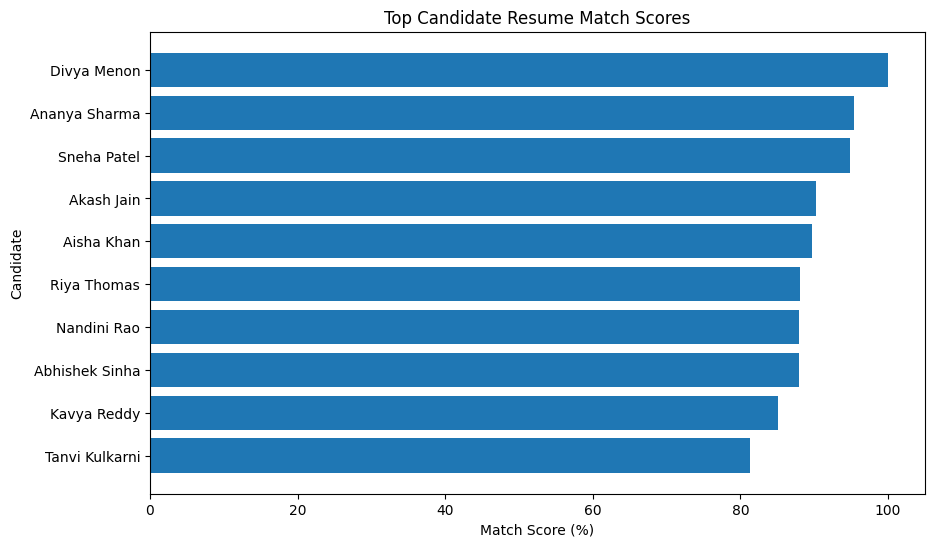

In [9]:
top_candidates = shortlist.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_candidates['Candidate_Name'], top_candidates['Match_Score'])
plt.xlabel('Match Score (%)')
plt.ylabel('Candidate')
plt.title('Top Candidate Resume Match Scores')
plt.gca().invert_yaxis()
plt.show()

## 8. Analytical Report

In [10]:
print('='*60)
print('JOB RESUME SCREENING ANALYTICAL REPORT')
print('='*60)
print('Total resumes:', len(df))
print('Shortlisted candidates:', len(shortlist))
print('\nRole-wise candidate count:')
print(shortlist['Best_Matched_Role'].value_counts())
print('\nTop candidates:')
for _, row in shortlist.head(10).iterrows():
    print(f"{row['Candidate_Name']} - {row['Best_Matched_Role']} - {row['Match_Score']:.2f}%")
print('\nConclusion: NLP can reduce manual resume screening time by extracting skills and ranking candidates according to job requirements.')

JOB RESUME SCREENING ANALYTICAL REPORT
Total resumes: 30
Shortlisted candidates: 30

Role-wise candidate count:
Best_Matched_Role
AI Engineer           7
Frontend Developer    6
Data Analyst          6
Java Developer        6
Data Scientist        5
Name: count, dtype: int64

Top candidates:
Divya Menon - Frontend Developer - 100.00%
Ananya Sharma - Data Scientist - 95.36%
Sneha Patel - Data Analyst - 94.81%
Akash Jain - Java Developer - 90.24%
Aisha Khan - AI Engineer - 89.65%
Riya Thomas - Data Analyst - 88.05%
Nandini Rao - Frontend Developer - 87.95%
Abhishek Sinha - Frontend Developer - 87.95%
Kavya Reddy - Java Developer - 85.09%
Tanvi Kulkarni - Data Scientist - 81.33%

Conclusion: NLP can reduce manual resume screening time by extracting skills and ranking candidates according to job requirements.


In [11]:
df.to_csv('resume_screening_results.csv', index=False)
shortlist.to_csv('candidate_shortlist.csv', index=False)
print('Saved: resume_screening_results.csv')
print('Saved: candidate_shortlist.csv')

Saved: resume_screening_results.csv
Saved: candidate_shortlist.csv
